<a href="https://colab.research.google.com/github/Manishalachu/DSL-datascience-/blob/main/prgm12dslco4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

12. Programs on convolutional neural network to classify images from any standard dataset in the public domain.

(50000, 32, 32, 3)
(10000, 32, 32, 3)


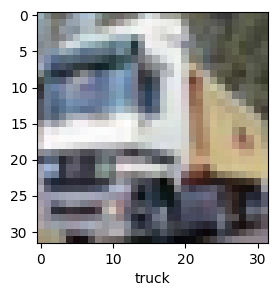

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4788 - loss: 1.4487 - val_accuracy: 0.5787 - val_loss: 1.1943
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6147 - loss: 1.0937 - val_accuracy: 0.6367 - val_loss: 1.0444
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.6594 - loss: 0.9742 - val_accuracy: 0.6507 - val_loss: 1.0081
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.6916 - loss: 0.8876 - val_accuracy: 0.6634 - val_loss: 0.9771
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7155 - loss: 0.8187 - val_accuracy: 0.6786 - val_loss: 0.9323
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.7322 - loss: 0.7671 - val_accuracy: 0.6933 - val_loss: 0.9001
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.7482 - loss: 0.7180 - val_accuracy: 0.6857 - val_loss: 0.9437
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.7653 -

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Load CIFAR-10 dataset
(xtrain, ytrain), (xtest, ytest) = datasets.cifar10.load_data()

print(xtrain.shape)
print(xtest.shape)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display sample image
def plot_sample(x, y, index):
    plt.figure(figsize=(3, 3))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index][0]])
    plt.show()

plot_sample(xtrain, ytrain, 1)

# Normalize
xtrain = xtrain.astype('float32') / 255.0
xtest = xtest.astype('float32') / 255.0

# CNN model
cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Feature extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = cnn.fit(
    xtrain,
    ytrain,
    epochs=20,
    validation_data=(xtest, ytest)
)

# Evaluate
test_loss, test_accuracy = cnn.evaluate(xtest, ytest)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Prediction
ypred = cnn.predict(xtest)

yclasses = [np.argmax(element) for element in ypred]

# Classification report
ytest_flat = ytest.reshape(-1)

print("Classification Report:")
print(
    classification_report(
        ytest_flat,
        yclasses,
        target_names=classes
    )
)